# Chuẩn bị dữ liệu giao dịch

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_customers = 5000
n_transactions = 30000

data = pd.DataFrame({
    "customer_id": np.random.randint(1, n_customers + 1, n_transactions),
    "date": pd.to_datetime("2025-01-01") + pd.to_timedelta(
        np.random.randint(0, 365, n_transactions), unit="D"
    ),
    "amount": np.random.gamma(shape=2.0, scale=50.0, size=n_transactions)
})

data.head()

,customer_id,date,amount
0,861,2025-01-07,93.756405
1,3773,2025-12-01,32.630012
2,3093,2025-01-03,32.882824
3,467,2025-09-15,169.225678
4,4427,2025-09-20,19.327047


In [2]:
data.tail()

,customer_id,date,amount
29995,2588,2025-01-08,148.998352
29996,4086,2025-03-15,56.986041
29997,558,2025-11-16,259.460796
29998,4714,2025-05-31,50.243411
29999,4120,2025-04-03,130.750708


In [3]:
data[data['customer_id'] == 1].sort_values(by="date")

,customer_id,date,amount
26170,1,2025-01-17,67.468364
23996,1,2025-03-10,41.064087
18436,1,2025-08-10,35.460547
15072,1,2025-08-28,140.201976


In [4]:
from datetime import date

d1 = date(2025, 1, 17)
d2 = date(2025, 8, 28)
delta = d2 - d1

print(f"t_x: {delta.days} days")

d1 = date(2025, 1, 17)
d2 = date(2025, 12, 31)
delta = d2 - d1

print(f"T: {delta.days} days")

# T : ngày đầu giao dịch đến ngày kết thúc quan sát
# t_x : ngày đầu giao dịch đến ngày giao dịch cuối cùng của khách hàng

t_x: 223 days
T: 348 days


# Tính x, t_x, T cho BG-NBD

In [10]:
from lifetimes.utils import summary_data_from_transaction_data

summary = summary_data_from_transaction_data(
    data,
    customer_id_col="customer_id",
    datetime_col="date",
    monetary_value_col="amount",
    observation_period_end="2025-12-31"
)


summary.head()
# x: số lần giao dịch của khách hàng trong khoảng thời gian quan sát (loại 1 transaction đầu tiên, chỉ tính từ transaction thứ 2 trở đi) - frequency


,frequency,recency,T,monetary_value
customer_id,,,,
1,3.0,223.0,348.0,72.242203
2,4.0,210.0,249.0,111.350175
3,5.0,204.0,245.0,90.770118
4,6.0,228.0,253.0,125.268220
5,3.0,214.0,361.0,96.195068


# Huấn luyện mô hình BG-NBD

BG-NBD cho biết khi nào khách quay lại & bao nhiêu lần

In [11]:
from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

summary["predicted_purchases_6m"] = bgf.predict(
    180,  # 6 tháng
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

# trả về Expected number of future transactions trong khoảng thời gian 6 tháng

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


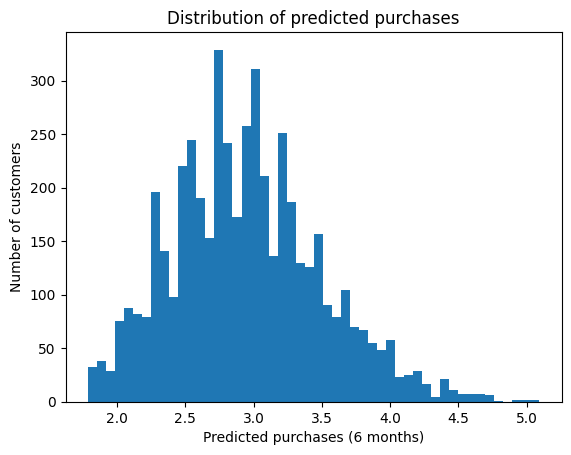

In [12]:
import matplotlib.pyplot as plt

plt.hist(summary["predicted_purchases_6m"], bins=50)
plt.xlabel("Predicted purchases (6 months)")
plt.ylabel("Number of customers")
plt.title("Distribution of predicted purchases")
plt.show()

# Huấn luyện mô hình Gamma–Gamma

Gamma-Gamma cho biết mỗi lần mua đáng bao nhiêu

In [13]:
from lifetimes import GammaGammaFitter

ggf = GammaGammaFitter(penalizer_coef=0.01)

summary_gg = summary[summary["monetary_value"] > 0]

ggf.fit(
    summary_gg["frequency"],
    summary_gg["monetary_value"]
)

summary.loc[summary_gg.index, "expected_avg_order_value"] = (
    ggf.conditional_expected_average_profit(
        summary_gg["frequency"],
        summary_gg["monetary_value"]
    )
)

# Model trả về: Expected average order value của khách hàng trong tương lai


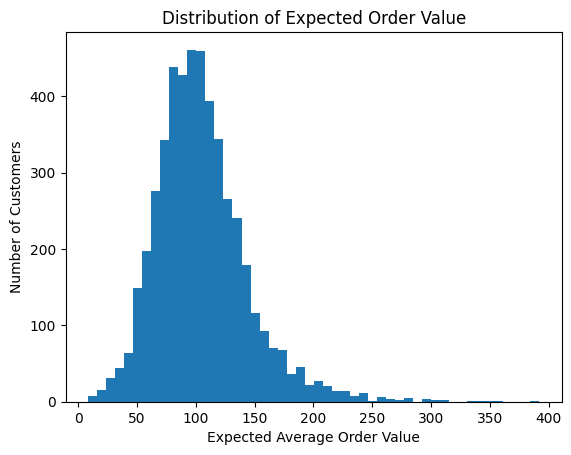

In [14]:
import matplotlib.pyplot as plt

plt.hist(summary["expected_avg_order_value"].dropna(), bins=50)
plt.xlabel("Expected Average Order Value")
plt.ylabel("Number of Customers")
plt.title("Distribution of Expected Order Value")
plt.show()

# Tính CLV cho từng khách hàng

CLV = expected purchases × expected order value × margin

In [15]:
summary["CLV_6m"] = ggf.customer_lifetime_value(
    bgf,
    summary["frequency"],
    summary["recency"],
    summary["T"],
    summary["monetary_value"],
    time=6,               # 6 tháng
    discount_rate=0.01,   # discount rate
    freq="D"
)
# discount rate là tỷ lệ chiết khấu hàng năm được sử dụng để tính giá trị hiện tại của các khoản thu nhập trong tương lai.
# Nó phản ánh sự mất giá trị của tiền theo thời gian, do đó, khi tính CLV, các khoản thu nhập trong tương lai sẽ được chiết khấu về giá trị hiện tại để phản ánh đúng giá trị của chúng đối với doanh nghiệp ngày hôm nay.

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


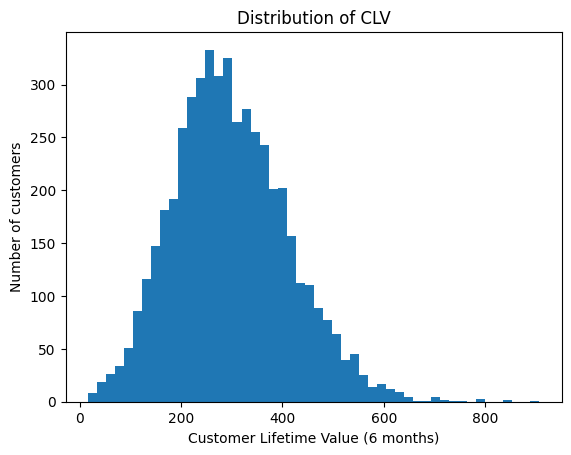

In [16]:
import matplotlib.pyplot as plt

plt.hist(summary["CLV_6m"].dropna(), bins=50)
plt.xlabel("Customer Lifetime Value (6 months)")
plt.ylabel("Number of customers")
plt.title("Distribution of CLV")
plt.show()

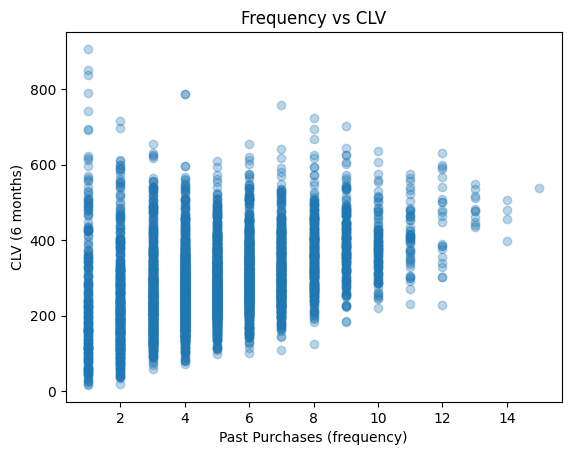

In [17]:
plt.scatter(summary["frequency"], summary["CLV_6m"], alpha=0.3)

plt.xlabel("Past Purchases (frequency)")
plt.ylabel("CLV (6 months)")
plt.title("Frequency vs CLV")
plt.show()

In [18]:
summary.sort_values("CLV_6m", ascending=False).head(10)

,frequency,recency,T,monetary_value,predicted_purchases_6m,expected_avg_order_value,CLV_6m
customer_id,,,,,,,
1298,1.0,18.0,168.0,347.490865,2.394985,391.747038,906.246649
2030,1.0,31.0,65.0,266.540244,2.916566,301.574093,849.578905
1403,1.0,59.0,93.0,278.611399,2.753549,315.020458,837.856197
4450,1.0,150.0,191.0,314.612441,2.303017,355.122929,789.975776
4664,4.0,93.0,96.0,207.318630,3.808685,213.833708,786.663628
3500,4.0,285.0,305.0,293.714155,2.692181,302.496194,786.614817
2952,7.0,146.0,195.0,189.085766,4.078921,192.496926,758.415191
429,1.0,13.0,77.0,238.159291,2.844396,269.959831,741.698124
4341,8.0,106.0,118.0,146.827977,5.018314,149.259992,723.500984


## Phân vùng High / Medium / Low Future Value 

Quantile-based segmentation:

- High Future Value:
    - Ưu tiên retention, VIP program, loyalty, upsell

- Medium Future Value:
    - Cross-sell, nudging campaign, bundle

- Low Future Value:
    - Discount nhẹ, win-back, hoặc giảm ngân sách marketing

In [22]:
summary["CLV_segment"] = pd.qcut(
    summary["CLV_6m"],
    q=[0, 0.7, 0.9, 1.0],
    labels=["Low Future Value", "Medium Future Value", "High Future Value"]
)

summary["CLV_segment"].value_counts()
# 70% là Low Future Value, 20% là Medium Future Value, 10% là High Future Value


CLV_segment
Low Future Value       3438
Medium Future Value     982
High Future Value       492
Name: count, dtype: int64

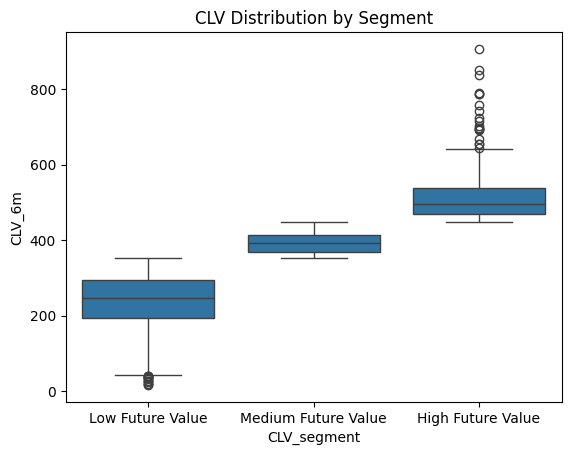

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="CLV_segment", y="CLV_6m", data=summary)

plt.title("CLV Distribution by Segment")
plt.show()